In [2]:
"""
Predicting USD/GBP exchange rates using LSTM neural networks.
The previous experiment had val_loss that didn't improve over epochs.

Hypothesis: Splitting chronelogically without shuffling the dataset led to poor generalization. Trends in the training set were not present in the test set.

Solution: Split the dataset as batches, then unbatch and shuffle the training and testing sets separately before re-batching.
This should give batches in both train and test with trends from different periods, improving generalization.
"""

"\nPredicting USD/GBP exchange rates using LSTM neural networks.\nThe previous experiment had val_loss that didn't improve over epochs.\n\nHypothesis: Splitting chronelogically without shuffling the dataset led to poor generalization. Trends in the training set were not present in the test set.\n\nSolution: Split the dataset as batches, then unbatch and shuffle the training and testing sets separately before re-batching.\nThis should give batches in both train and test with trends from different periods, improving generalization.\n"

In [3]:
from datetime import datetime, timedelta
import os
import pandas as pd
import glob

now = datetime.now().strftime("%Y%m%d_%H%M%S")

EXPERIMENT_NAME = f"usdgbp_forecast_{now}"

# makedir for experiment
os.makedirs(EXPERIMENT_NAME, exist_ok=True)

DATA_DIR = "data"

# Load all CSV files from data directory
csv_files = glob.glob(os.path.join(DATA_DIR, "GBPUSD*.csv"))
print(f"Found {len(csv_files)} CSV files: {csv_files}")

dfs = []
for csv_file in csv_files:
    # Read header from row 0, skip rows 1 and 2 (ticker info and 'Datetime' label)
    df_temp = pd.read_csv(csv_file, header=0, skiprows=[1, 2], parse_dates=[0], index_col=0)
    df_temp.index.name = "Datetime"
    print(f"Loaded {csv_file}: {len(df_temp)} rows")
    dfs.append(df_temp)

# Combine all dataframes
df = pd.concat(dfs)

# Remove timezone info if present
if df.index.tz is not None:
    df.index = df.index.tz_localize(None)

# Remove duplicate rows by datetime index
df = df[~df.index.duplicated(keep='first')]

# Sort by datetime
df = df.sort_index()

print(f"\nTotal rows after deduplication: {len(df)}")

# prove that there are no duplicate indices
assert not df.index.duplicated().any(), "There are still duplicate datetime indices!"

# TODO check values will always be between 0 and 1
for column in df.columns:
    print(f"{column} max: {df[column].max()}")
    print(f"{column} min: {df[column].min()}")

# Days when the markets are closed are not included in the dataset by default !
print(df.iloc[2735:2740])


Found 4 CSV files: ['data/GBPUSD=X_1m_2026-01-08_to_2026-01-09.csv', 'data/GBPUSD=X_1m_2026-01-05_to_2026-01-06.csv', 'data/GBPUSD=X_1m_2025-12-22_to_2025-12-30.csv', 'data/GBPUSD=X_1m_2025-12-23_to_2025-12-31.csv']
Loaded data/GBPUSD=X_1m_2026-01-08_to_2026-01-09.csv: 2095 rows
Loaded data/GBPUSD=X_1m_2026-01-05_to_2026-01-06.csv: 2393 rows
Loaded data/GBPUSD=X_1m_2025-12-22_to_2025-12-30.csv: 8642 rows
Loaded data/GBPUSD=X_1m_2025-12-23_to_2025-12-31.csv: 8254 rows

Total rows after deduplication: 14173
Close max: 1.3567785024642944
Close min: 1.3379716873168943
High max: 1.3567785024642944
High min: 1.3379716873168943
Low max: 1.3567785024642944
Low min: 1.3379716873168943
Open max: 1.3567785024642944
Open min: 1.3379716873168943
Volume max: 0
Volume min: 0
                        Close      High       Low      Open  Volume
Datetime                                                           
2025-12-23 22:01:00  1.349619  1.349619  1.349619  1.349619       0
2025-12-23 22:02:00  1.34

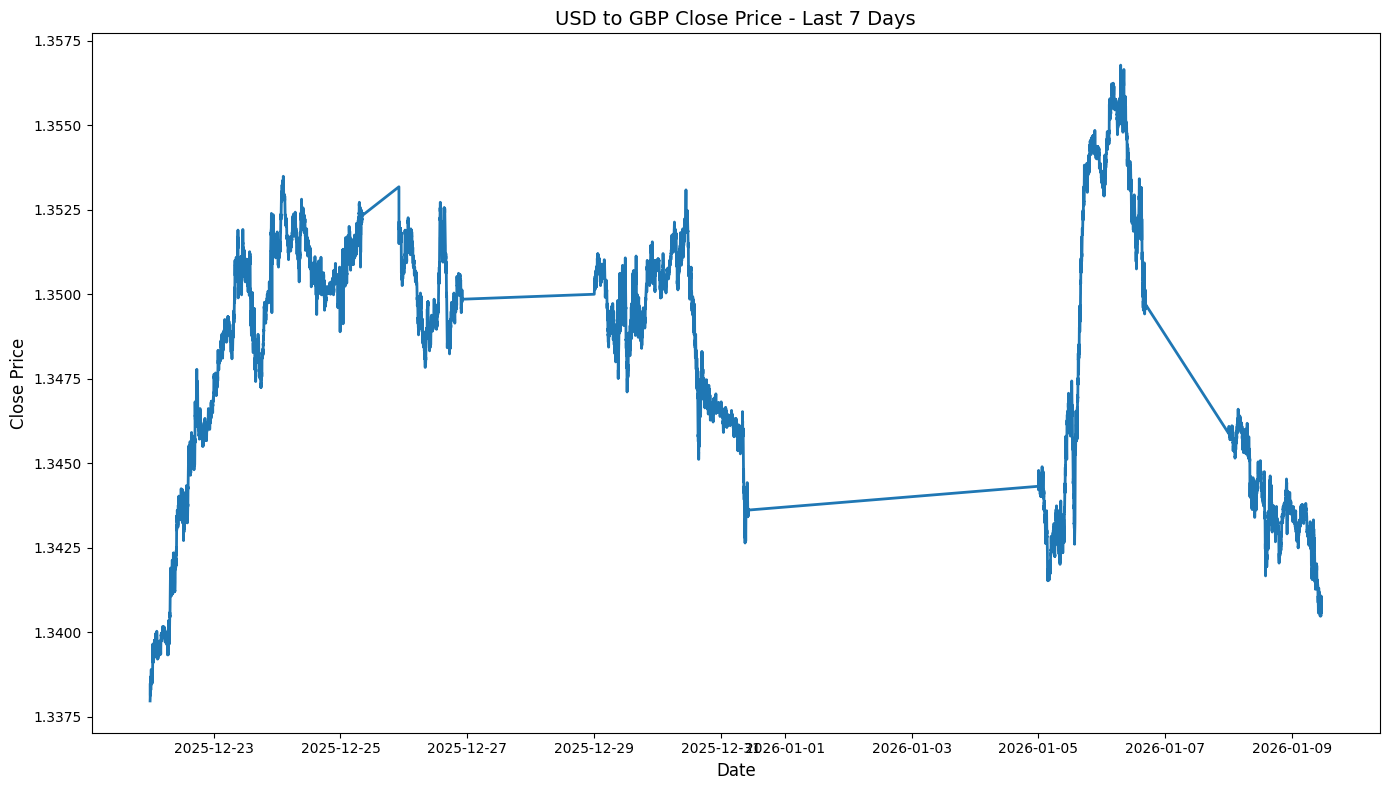

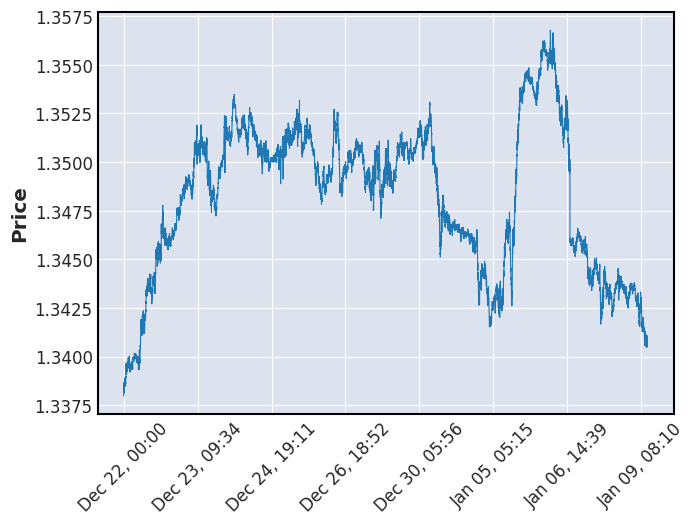

In [4]:
# use matplot to plot close price
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 8))
plt.plot(df.index, df['Close'], linewidth=2)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Close Price', fontsize=12)
plt.title('USD to GBP Close Price - Last 7 Days', fontsize=14)
plt.tight_layout()
plt.show()

# plot full week candlestick chart
import mplfinance as mpf

df_plot = df.copy()

df_plot.index.name = 'Date'

mpf.plot(df_plot, type='line')


In [5]:
import tensorflow as tf
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import joblib

# Parameters
SEQUENCE_LENGTH = 30
FORECAST_LENGTH = 5

# Remove any NaN values
df_clean = df.dropna()

# keep only training columns
df_clean = df_clean.reset_index()

# Hour of day (0-23)
# df_clean["Hour_sin"] = np.sin(2 * np.pi * df_clean["Datetime"].dt.hour / 24)
# df_clean["Hour_cos"] = np.cos(2 * np.pi * df_clean["Datetime"].dt.hour / 24)

# # Minute of hour (0-59)
# df_clean["Minute_sin"] = np.sin(2 * np.pi * df_clean["Datetime"].dt.minute / 60)
# df_clean["Minute_cos"] = np.cos(2 * np.pi * df_clean["Datetime"].dt.minute / 60)

# # Day of week (0-6)
# df_clean["DayOfWeek_sin"] = np.sin(2 * np.pi * df_clean["Datetime"].dt.dayofweek / 7)
# df_clean["DayOfWeek_cos"] = np.cos(2 * np.pi * df_clean["Datetime"].dt.dayofweek / 7)

df_clean = df_clean[
    [
        "Datetime",
        "Open",
        "High",
        "Low",
        "Close",
        # "Hour_sin",
        # "Hour_cos",
        # "Minute_sin",
        # "Minute_cos",
        # "DayOfWeek_sin",
        # "DayOfWeek_cos",
    ]
]  # TODO test with time cos sin features

# Scale the features
feature_cols = ["Open", "High", "Low", "Close"]
scaler = MinMaxScaler()
df_clean[feature_cols] = scaler.fit_transform(df_clean[feature_cols])

# Save scaler for later inverse transformation
joblib.dump(scaler, os.path.join(EXPERIMENT_NAME, "scaler.pkl"))

# Close is the last column (index 3), needed for inverse transform
CLOSE_COL_IDX = feature_cols.index("Close")
print(f"Close column index: {CLOSE_COL_IDX}")

# Create sequences
X = []
y = []
time_delta_issues = 0

for i in range(len(df_clean) - SEQUENCE_LENGTH - FORECAST_LENGTH + 1):
    # Remove sequences with large time deltas
    if (
        df_clean.iloc[i : i + SEQUENCE_LENGTH + FORECAST_LENGTH]["Datetime"].diff()
        > timedelta(minutes=10)
    ).any():
        time_delta_issues += 1
        continue

    # Get 30 minutes of data as input
    x_seq = df_clean.iloc[i : i + SEQUENCE_LENGTH].drop(['Datetime'], axis=1).values
    
    # Get next 5 minutes as output
    y_seq = df_clean.iloc[i + SEQUENCE_LENGTH : i + SEQUENCE_LENGTH + FORECAST_LENGTH][
        "Close"
    ].values

    X.append(x_seq)
    y.append(y_seq)
print(f"Number of sequences with time delta issues: {time_delta_issues}")
X = np.array(X)
y = np.array(y)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Number of samples: {len(X)}")

# Create TensorFlow dataset
dataset = tf.data.Dataset.from_tensor_slices((X, y))
dataset = dataset.batch(32)

train, test = tf.keras.utils.split_dataset(
    dataset, left_size=0.8, shuffle=False, seed=42
)

train = train.unbatch().shuffle(buffer_size=1000).batch(32)
test = test.unbatch().shuffle(buffer_size=1000).batch(32)

print(f"\nTraining set batches: {len(list(train))}")
print(f"Testing set batches: {len(list(test))}")


input_features = len(X[0][0])
print(f"Input features: {input_features}")

2026-01-09 12:07:18.397867: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-01-09 12:07:18.433327: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-09 12:07:20.078476: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-09 12:07:24.278927: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off,

Close column index: 3
Number of sequences with time delta issues: 170
X shape: (13969, 30, 4)
y shape: (13969, 5)
Number of samples: 13969


2026-01-09 12:07:39.464942: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
2026-01-09 12:07:42.276285: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence



Training set batches: 350
Testing set batches: 88
Input features: 4


2026-01-09 12:07:42.480560: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [ ]:
# Bayesian Optimization of LSTM Hyperparameters
import keras_tuner as kt
from tensorflow.keras.callbacks import EarlyStopping

OUTPUT_FEATURES = 1  # Predict only the 'Close' price


def build_model(hp):
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.InputLayer(shape=(SEQUENCE_LENGTH, input_features)))
    model.add(
        tf.keras.layers.LSTM(
            units=hp.Int("units", min_value=32, max_value=256, step=32),
            return_sequences=False,
        )
    )
    model.add(
        tf.keras.layers.Dropout(
            hp.Float("dropout", min_value=0.1, max_value=0.5, step=0.1)
        )
    )
    model.add(
        tf.keras.layers.Dense(
            FORECAST_LENGTH * OUTPUT_FEATURES,  # Output: (batch, 5)
        )
    )
    # No Reshape needed - output is (batch, 5) matching target y shape
    model.compile(
        optimizer=tf.keras.optimizers.Adam(hp.Float("learning_rate", 1e-4, 1e-2)),
        loss="mse",
    )
    return model


tuner = kt.BayesianOptimization(
    build_model,
    objective="val_loss",
    max_trials=30,
    directory=f"{EXPERIMENT_NAME}/lstm_tuning",
    project_name="usd_gbp_forecasting",
)

tuner.search(
    train.take(len(list(train)) // 3),
    epochs=30,
    validation_data=test.take(len(list(test)) // 3),
    callbacks=[
        EarlyStopping(
            monitor="val_loss",
            patience=10,
            restore_best_weights=True,
            start_from_epoch=5,
        )
    ],
)

print(tuner.results_summary())

# get best parameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

# create model with best hyperparameters
model = tuner.hypermodel.build(best_hps)

Trial 2 Complete [00h 01m 36s]
val_loss: 0.00023624056484550238

Best val_loss So Far: 0.00023624056484550238
Total elapsed time: 00h 02m 23s

Search: Running Trial #3

Value             |Best Value So Far |Hyperparameter
192               |96                |units
0.2               |0.4               |dropout
0.0074219         |0.0057904         |learning_rate

Epoch 1/30
116/116 ━━━━━━━━━━━━━━━━━━━━ 8s 53ms/step - loss: 0.0055 - val_loss: 4.3104e-04
Epoch 2/30
116/116 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step - loss: 0.0010 - val_loss: 0.0010
Epoch 3/30
116/116 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step - loss: 0.0010 - val_loss: 0.0017
Epoch 4/30
116/116 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - loss: 8.5738e-04 - val_loss: 4.0301e-04
Epoch 5/30
116/116 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step - loss: 5.7735e-04 - val_loss: 5.3379e-04
Epoch 6/30
116/116 ━━━━━━━━━━━━━━━━━━━━ 6s 53ms/step - loss: 6.0496e-04 - val_loss: 7.0096e-04
Epoch 7/30
116/116 ━━━━━━━━━━━━━━━━━━━━ 8s 65ms/step - loss: 5.2929e-04 - val_loss: 4

2026-01-09 12:12:55.417097: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


116/116 ━━━━━━━━━━━━━━━━━━━━ 8s 66ms/step - loss: 3.4751e-04 - val_loss: 4.3397e-04
Epoch 18/30
116/116 ━━━━━━━━━━━━━━━━━━━━ 7s 64ms/step - loss: 3.6774e-04 - val_loss: 4.4859e-04
Epoch 19/30
116/116 ━━━━━━━━━━━━━━━━━━━━ 7s 56ms/step - loss: 3.4065e-04 - val_loss: 7.8006e-04
Epoch 20/30
116/116 ━━━━━━━━━━━━━━━━━━━━ 7s 63ms/step - loss: 2.9172e-04 - val_loss: 5.1127e-04
Epoch 21/30
 19/116 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - loss: 2.7766e-04

In [ ]:
model.fit(
    train,
    epochs=100,
    validation_data=test,
    callbacks=[
        EarlyStopping(
            monitor="val_loss",
            patience=10,
            restore_best_weights=True,
            start_from_epoch=5,
        )
    ],
)

model.save(os.path.join(EXPERIMENT_NAME, "usdgbp_lstm_model.keras"))

Epoch 1/100
    298/Unknown 7s 20ms/step - loss: 0.0087

/home/unix/.pyenv/versions/finance/lib/python3.13/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


298/298 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - loss: 0.0032 - val_loss: 2.6648e-04
Epoch 2/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - loss: 7.8243e-04 - val_loss: 2.4513e-04
Epoch 3/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - loss: 6.5603e-04 - val_loss: 2.1693e-04
Epoch 4/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - loss: 5.2726e-04 - val_loss: 2.5107e-04
Epoch 5/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - loss: 4.6366e-04 - val_loss: 5.1071e-04
Epoch 6/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - loss: 4.1812e-04 - val_loss: 2.5577e-04
Epoch 7/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - loss: 3.6106e-04 - val_loss: 2.3159e-04
Epoch 8/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - loss: 3.2707e-04 - val_loss: 2.3832e-04
Epoch 9/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - loss: 3.0840e-04 - val_loss: 2.4699e-04
Epoch 10/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - loss: 2.7715e-04 - val_loss: 3.0120e-04
Epoch 11/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step 

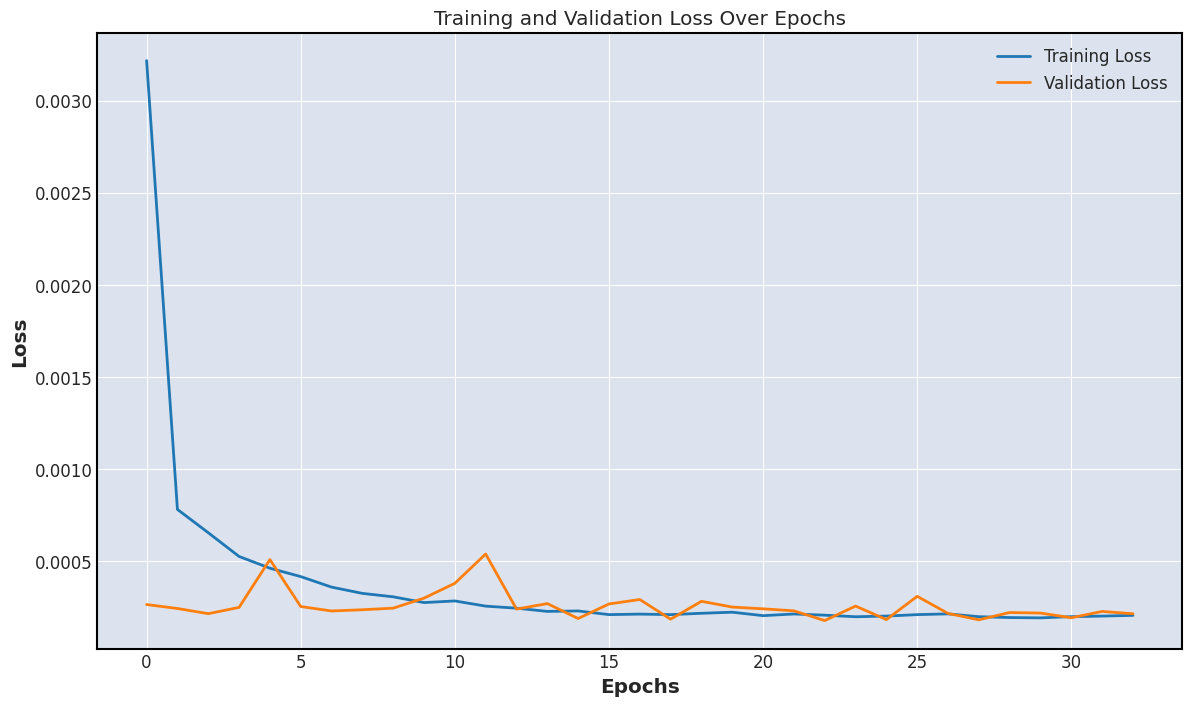

In [ ]:
# plot training history
history = model.history.history
plt.figure(figsize=(14, 8))
plt.plot(history['loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.legend()
plt.savefig(os.path.join(EXPERIMENT_NAME, "training_validation_loss.png"))
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


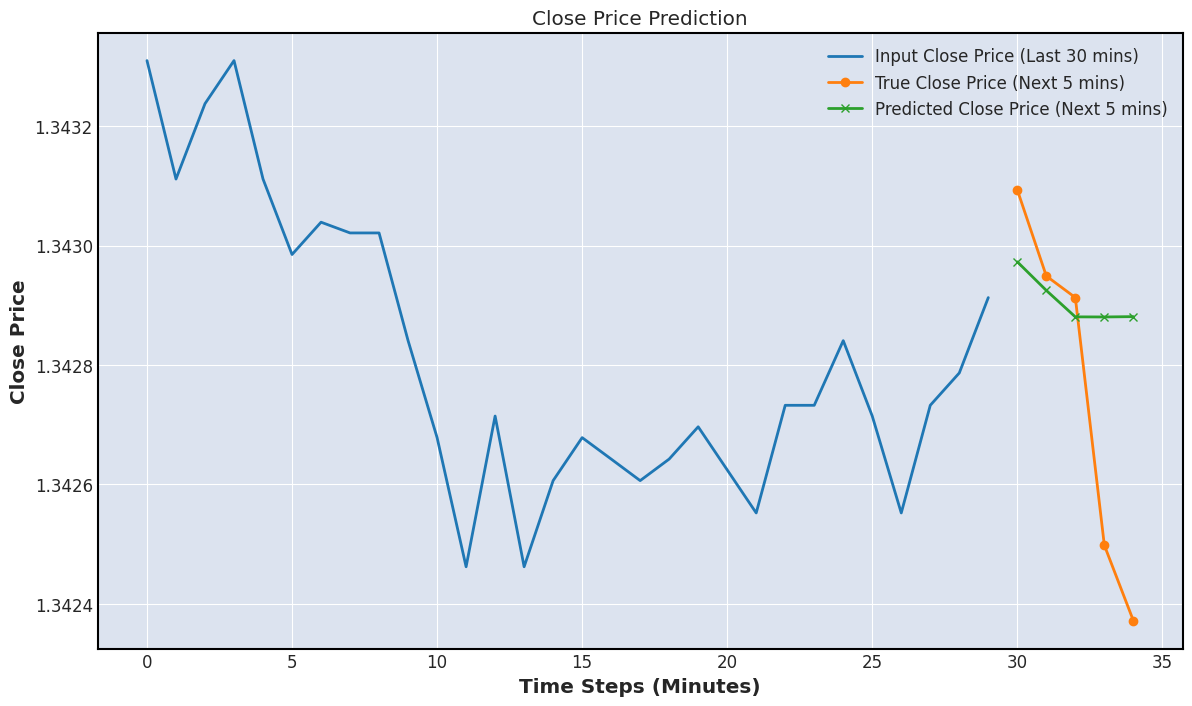

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


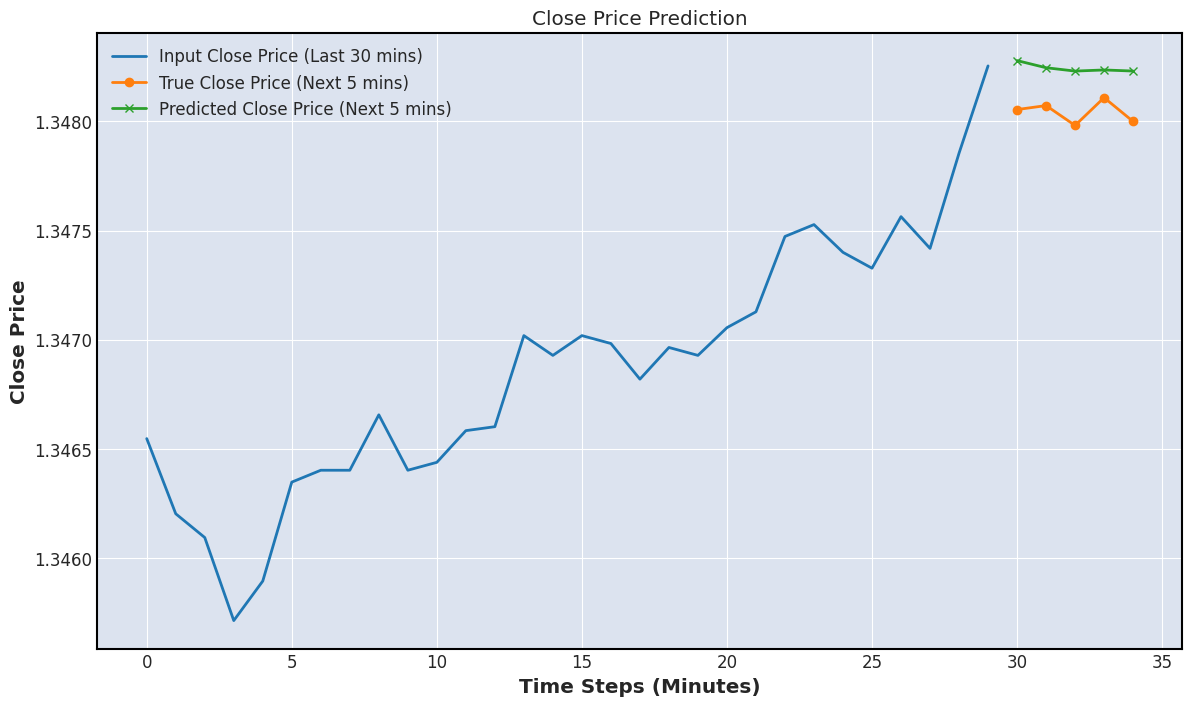

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


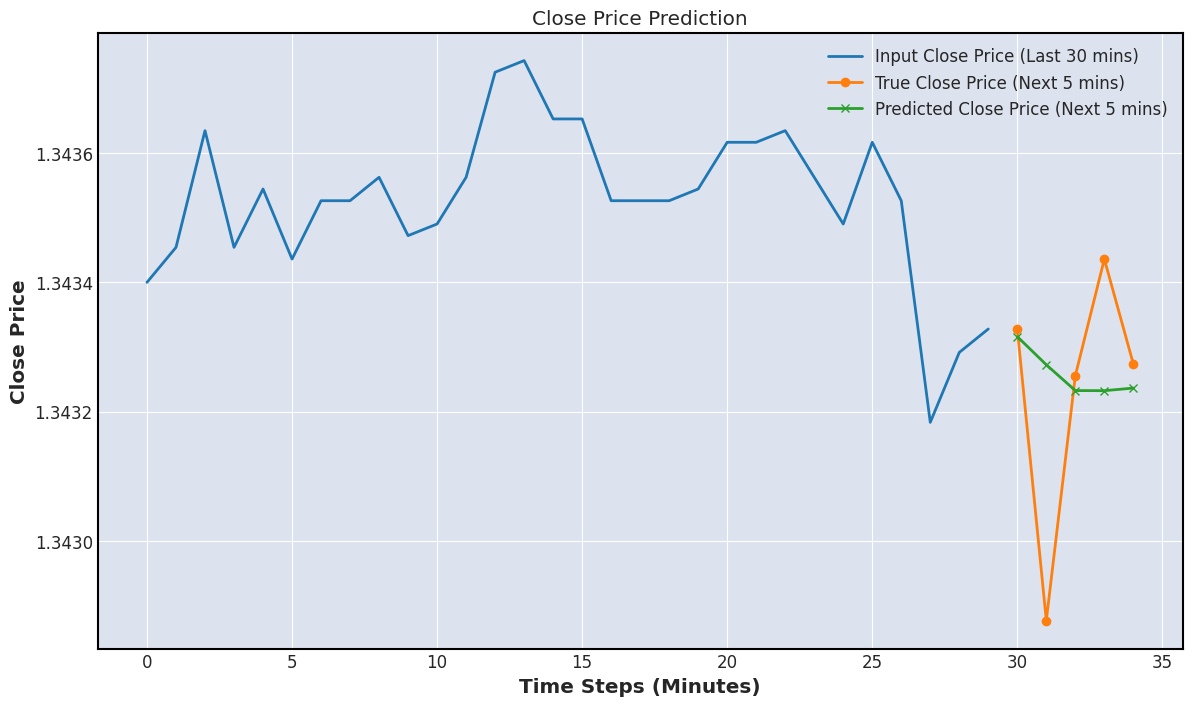

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


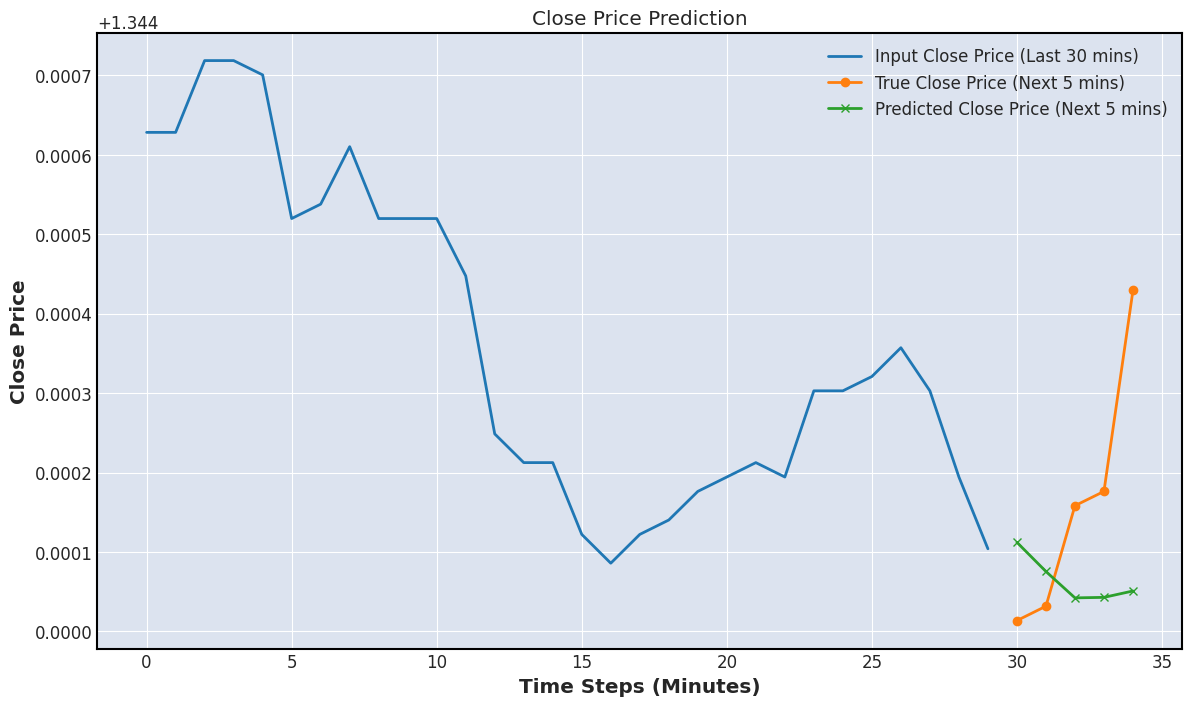

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


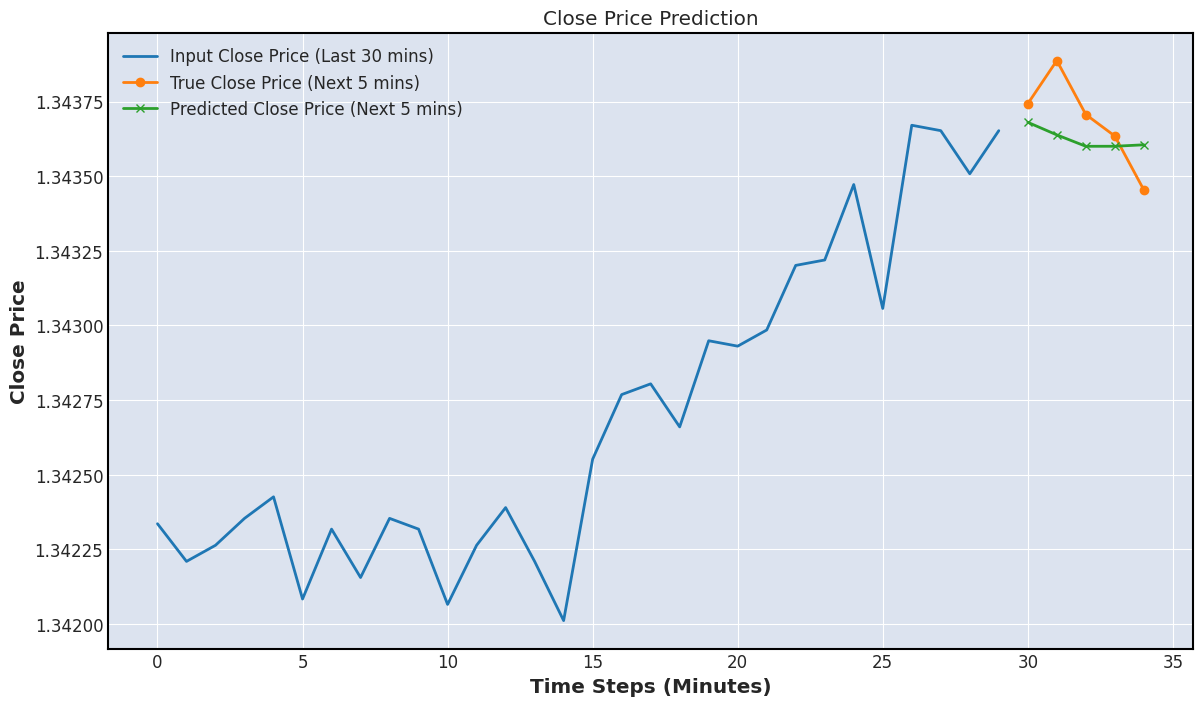

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


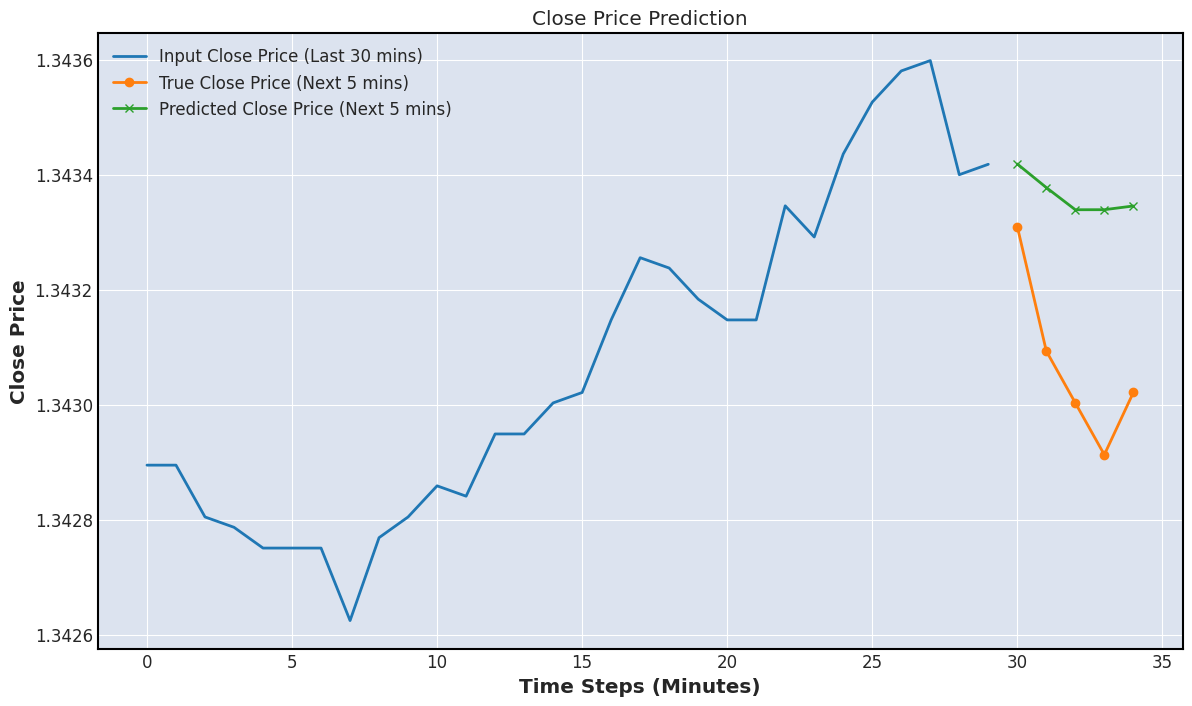

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


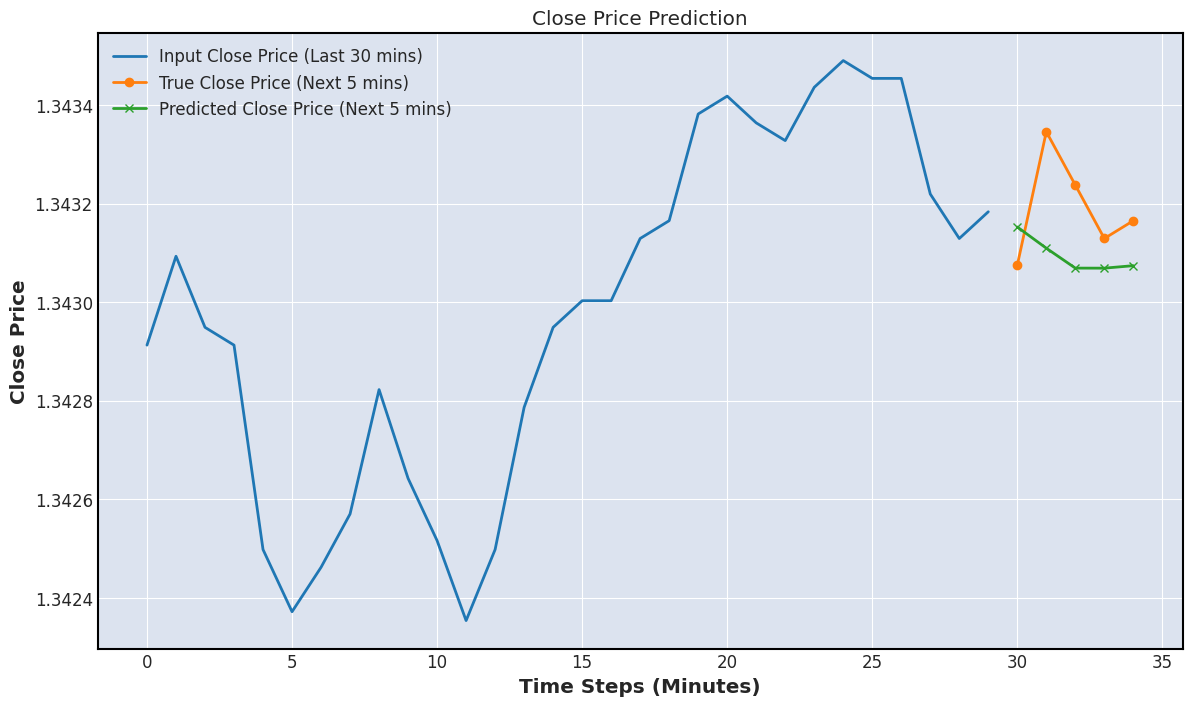

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


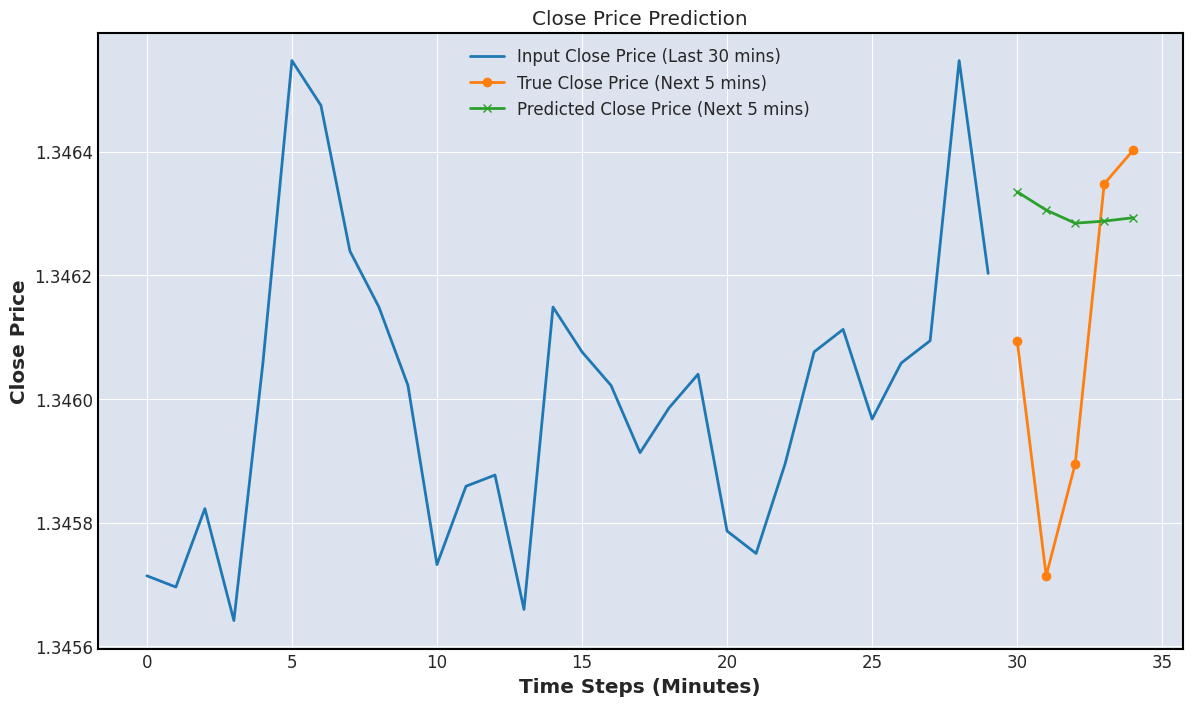

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


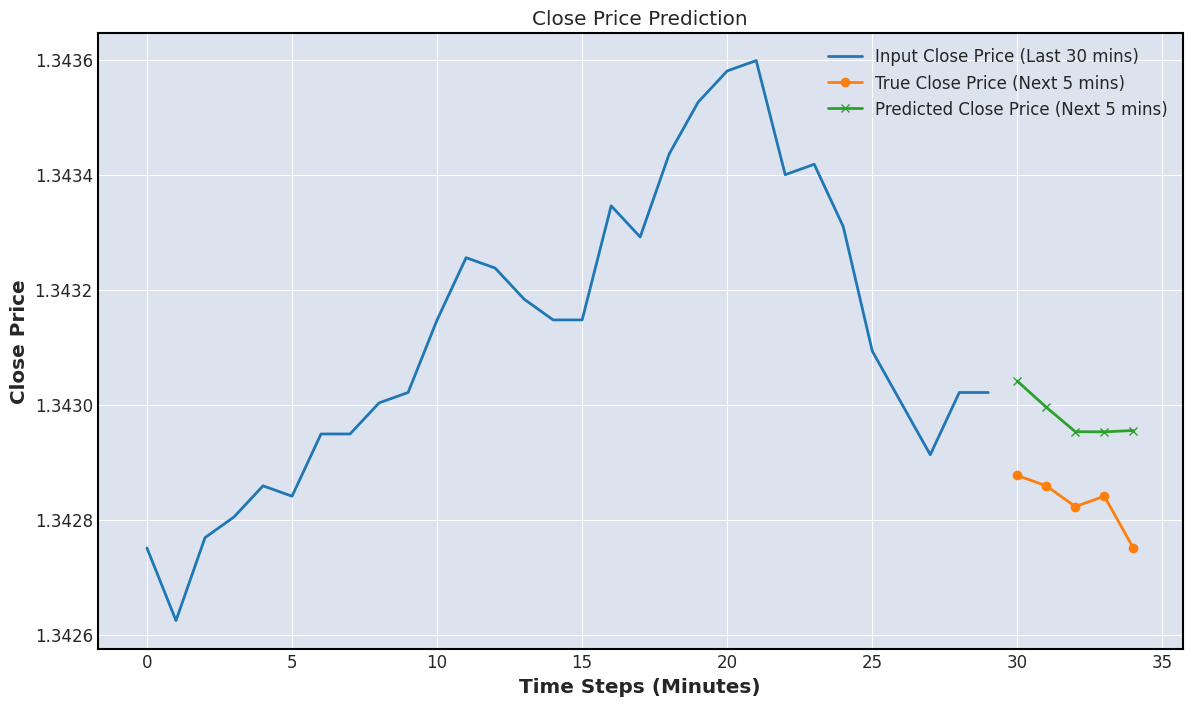

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


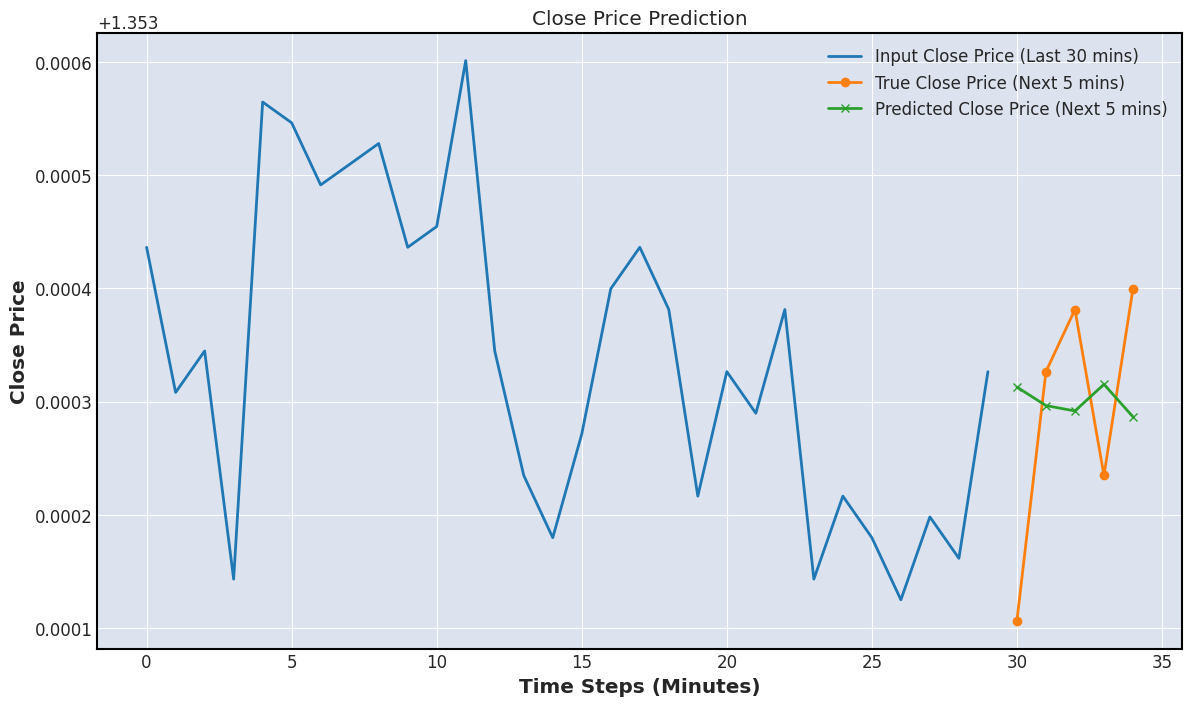

In [ ]:
# plot X sequence and predicted vs actual y for the first sequence from test set. Close is the last column in X

def inverse_transform_close(scaled_values):
    """Inverse transform Close prices from scaled values."""
    # Create dummy array with same shape as scaler expects (4 features)
    dummy = np.zeros((len(scaled_values), len(feature_cols)))
    dummy[:, CLOSE_COL_IDX] = scaled_values
    return scaler.inverse_transform(dummy)[:, CLOSE_COL_IDX]

i = 1
for X_batch, y_batch in test.take(10):
    X_sample = X_batch[0].numpy()
    y_true_scaled = y_batch[0].numpy()
    y_pred_scaled = model.predict(X_batch)[0]

    # Inverse transform for plotting in original scale
    X_close_original = inverse_transform_close(X_sample[:, -1])
    y_true_original = inverse_transform_close(y_true_scaled)
    y_pred_original = inverse_transform_close(y_pred_scaled)

    plt.figure(figsize=(14, 8))
    plt.plot(range(SEQUENCE_LENGTH), X_close_original, label='Input Close Price (Last 30 mins)')
    plt.plot(range(SEQUENCE_LENGTH, SEQUENCE_LENGTH + FORECAST_LENGTH), y_true_original, label='True Close Price (Next 5 mins)', marker='o')
    plt.plot(range(SEQUENCE_LENGTH, SEQUENCE_LENGTH + FORECAST_LENGTH), y_pred_original, label='Predicted Close Price (Next 5 mins)', marker='x')
    plt.xlabel('Time Steps (Minutes)')
    plt.ylabel('Close Price')
    plt.title('Close Price Prediction')
    plt.legend()
    plt.savefig(os.path.join(EXPERIMENT_NAME, f"close_price_prediction_{i}.png"))
    plt.show()
    i += 1

In [ ]:
# Calculate loss metrics on full test set
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Collect all predictions and true values
all_y_true = []
all_y_pred = []

for X_batch, y_batch in test:
    y_pred_batch = model.predict(X_batch, verbose=0)
    all_y_true.append(y_batch.numpy())
    all_y_pred.append(y_pred_batch)

all_y_true = np.concatenate(all_y_true, axis=0)
all_y_pred = np.concatenate(all_y_pred, axis=0)

# Calculate metrics on scaled data
mse_scaled = mean_squared_error(all_y_true, all_y_pred)
mae_scaled = mean_absolute_error(all_y_true, all_y_pred)
rmse_scaled = np.sqrt(mse_scaled)

print("=== Test Set Metrics (Scaled) ===")
print(f"MSE:  {mse_scaled:.6f}")
print(f"RMSE: {rmse_scaled:.6f}")
print(f"MAE:  {mae_scaled:.6f}")

# Inverse transform for original scale metrics
all_y_true_original = np.array([inverse_transform_close(y) for y in all_y_true])
all_y_pred_original = np.array([inverse_transform_close(y) for y in all_y_pred])

mse_original = mean_squared_error(all_y_true_original, all_y_pred_original)
mae_original = mean_absolute_error(all_y_true_original, all_y_pred_original)
rmse_original = np.sqrt(mse_original)

print("\n=== Test Set Metrics (Original Scale) ===")
print(f"MSE:  {mse_original:.8f}")
print(f"RMSE: {rmse_original:.6f}")
print(f"MAE:  {mae_original:.6f}")

# Calculate per-timestep errors
errors = all_y_pred_original - all_y_true_original
errors_flat = errors.flatten()

# --- Visualization 1: Error Distribution ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histogram of errors
axes[0, 0].hist(errors_flat, bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Prediction Error')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Prediction Errors')

# Predicted vs Actual scatter plot
axes[0, 1].scatter(all_y_true_original.flatten(), all_y_pred_original.flatten(), alpha=0.3, s=5)
min_val = min(all_y_true_original.min(), all_y_pred_original.min())
max_val = max(all_y_true_original.max(), all_y_pred_original.max())
axes[0, 1].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
axes[0, 1].set_xlabel('Actual Close Price')
axes[0, 1].set_ylabel('Predicted Close Price')
axes[0, 1].set_title('Predicted vs Actual Close Price')
axes[0, 1].legend()

# Per-timestep MAE
timestep_mae = np.mean(np.abs(errors), axis=0)
axes[1, 0].bar(range(1, FORECAST_LENGTH + 1), timestep_mae, color='steelblue', edgecolor='black')
axes[1, 0].set_xlabel('Forecast Timestep (minutes ahead)')
axes[1, 0].set_ylabel('Mean Absolute Error')
axes[1, 0].set_title('MAE per Forecast Timestep')
axes[1, 0].set_xticks(range(1, FORECAST_LENGTH + 1))

# Box plot of errors per timestep
axes[1, 1].boxplot([errors[:, i] for i in range(FORECAST_LENGTH)], labels=[f't+{i+1}' for i in range(FORECAST_LENGTH)])
axes[1, 1].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[1, 1].set_xlabel('Forecast Timestep')
axes[1, 1].set_ylabel('Prediction Error')
axes[1, 1].set_title('Error Distribution per Forecast Timestep')

plt.tight_layout()
plt.savefig(os.path.join(EXPERIMENT_NAME, "test_set_error_analysis.png"), dpi=150)
plt.show()

# --- Visualization 2: Residual Analysis ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals vs predicted values
axes[0].scatter(all_y_pred_original.flatten(), errors_flat, alpha=0.3, s=5)
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel('Predicted Close Price')
axes[0].set_ylabel('Residual (Predicted - Actual)')
axes[0].set_title('Residuals vs Predicted Values')

# Q-Q plot approximation - sorted residuals vs expected normal
from scipy import stats
stats.probplot(errors_flat, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot of Residuals')

plt.tight_layout()
plt.savefig(os.path.join(EXPERIMENT_NAME, "residual_analysis.png"), dpi=150)
plt.show()

print(f"\nTotal test samples evaluated: {len(all_y_true)}")
print(f"Mean prediction error: {np.mean(errors_flat):.6f}")
print(f"Std of prediction error: {np.std(errors_flat):.6f}")

NameError: name 'test' is not defined

In [ ]:
# Save a snapshot of this notebook to the experiment directory
import shutil
from datetime import datetime

notebook_path = "main.ipynb"
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
snapshot_name = f"main_snapshot_{timestamp}.ipynb"
snapshot_path = os.path.join(EXPERIMENT_NAME, snapshot_name)

shutil.copy(notebook_path, snapshot_path)
print(f"Notebook snapshot saved to: {snapshot_path}")

Notebook snapshot saved to: usdgbp_forecast_007/main_snapshot_20260106_182558.ipynb
